In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle as pkl
import json
import seaborn as sns

In [2]:
# load in predictions from all models

SEQ_LENGTH = 24*7

with open('../data/processed/Lasso_preds.pkl', 'rb') as f:
    lasso_preds = pkl.load(f)

with open('../data/processed/OLS_preds.pkl', 'rb') as f:
    OLS_preds = pkl.load(f)

with open('../data/processed/XGBoost_preds.pkl', 'rb') as f:
    xgb_preds = pkl.load(f)

with open('../data/processed/naive_1wk_preds.pkl', 'rb') as f:
    naive_1wk_preds = pkl.load(f)

with open('../data/processed/naive_1hr_preds.pkl', 'rb') as f:
    naive_1hr_preds = pkl.load(f)

with open('../data/processed/LSTM_preds_dict.pkl', 'rb') as f:
    LSTM_preds = pkl.load(f)

with open('../data/processed/df_seq_test.pkl', 'rb') as f:
    datetime_for_tests_LSTM = pd.to_datetime(pkl.load(f).index.get_level_values('datetime').unique())
    datetime_for_tests_LSTM = datetime_for_tests_LSTM[:len(datetime_for_tests_LSTM) - SEQ_LENGTH]

In [3]:
# concat the linear and tree based models to get df with all predictions
df_all_preds = df_all_preds = pd.concat((
                                xgb_preds.rename(columns={'y_pred': 'xgb'}),
                                lasso_preds.rename(columns={'y_pred': 'lasso'})['lasso'],
                                OLS_preds.rename(columns={'y_pred': 'OLS'})['OLS'],                     
                                naive_1hr_preds.rename(columns={'y_pred': 'naive_1hr'})['naive_1hr'],                     
                                naive_1wk_preds.rename(columns={'y_pred': 'naive_1wk'})['naive_1wk'],                     
                                        ), axis=1)

# reset and set index again to ensure datetime
df_all_preds.reset_index(inplace=True)
df_all_preds['datetime'] = pd.to_datetime(df_all_preds['datetime'])
df_all_preds.set_index(['datetime', 'client_id'], inplace=True)

In [4]:
# create dataframe from LSTM preds
df_LSTM = pd.DataFrame(LSTM_preds).set_index(datetime_for_tests_LSTM)
# take advantage of wide form to assign datetime (each row represents one datetime)
df_LSTM['datetime'] = datetime_for_tests_LSTM
# then melt so that client id becomes identifier column
df_LSTM = df_LSTM.melt(id_vars=['datetime']).rename(columns={'variable': 'client_id',
                                                             'value': 'LSTM'}).set_index(['datetime', 'client_id'])

In [5]:
# remove datetimes from other models that LSTM does not predict
df_all_preds_filtered = df_all_preds[df_all_preds.index.get_level_values('datetime').isin(datetime_for_tests_LSTM)]

In [6]:
# now concat LSTM and XGBoost together
df_all_preds_filtered = df_all_preds_filtered.join(df_LSTM, on=['datetime', 'client_id'], how='inner')

In [11]:
df_all_preds_filtered.iloc[1000:1010]

,,xgb,y_true,lasso,OLS,naive_1hr,naive_1wk,LSTM
datetime,client_id,,,,,,,
2014-04-25 12:00:00,16,31.131601,39.293850,31.574071,32.439071,30.894077,36.588838,29.994728
2014-04-25 13:00:00,16,38.709709,41.714123,36.234507,38.538194,39.293850,42.710706,27.725582
2014-04-25 14:00:00,16,36.461010,31.890661,33.808886,35.415827,41.714123,34.880410,27.384338
2014-04-25 15:00:00,16,32.384716,36.731207,31.882675,31.586468,31.890661,40.575171,29.070345
2014-04-25 16:00:00,16,38.289997,35.022779,33.703107,35.546161,36.731207,42.995444,25.201601
2014-04-25 17:00:00,16,33.594597,34.026196,30.443864,31.003790,35.022779,34.453303,24.954605
2014-04-25 18:00:00,16,31.199940,31.321185,29.680149,29.726514,34.026196,29.470387,23.380554
2014-04-25 19:00:00,16,31.920744,37.443052,31.035545,30.586109,31.321185,33.456720,24.752312
2014-04-25 20:00:00,16,38.469528,35.022779,36.223872,37.318683,37.443052,37.870159,28.580683


In [7]:
# save the filtered predictions
with open('../data/processed/df_all_preds', 'wb') as f:
    pkl.dump(df_all_preds, f)

In [8]:
df_all_preds_filtered.index.get_level_values('client_id').unique()

Index([ 16,  21,  23,  24,  25,  27,  28,  35,  36,  44,  49,  51,  53,  55,
        60,  62,  65,  75,  80,  84, 101, 103, 104, 114, 119, 123, 124, 125,
       128, 132, 136, 139, 141, 145, 147, 149, 150, 151, 156, 161, 164, 165,
       166, 167, 170, 172, 182, 185, 194, 195, 200, 204, 206, 209, 210, 217,
       219, 222, 225, 229, 231, 235, 238, 239, 240, 241, 245, 247, 249, 250,
       253, 254, 255, 262, 268, 269, 272, 277, 281, 282, 293, 296, 300, 301,
       303, 304, 307, 317, 319, 321, 324, 327, 328, 329, 330, 336, 343, 354,
       366, 370],
      dtype='int64', name='client_id')

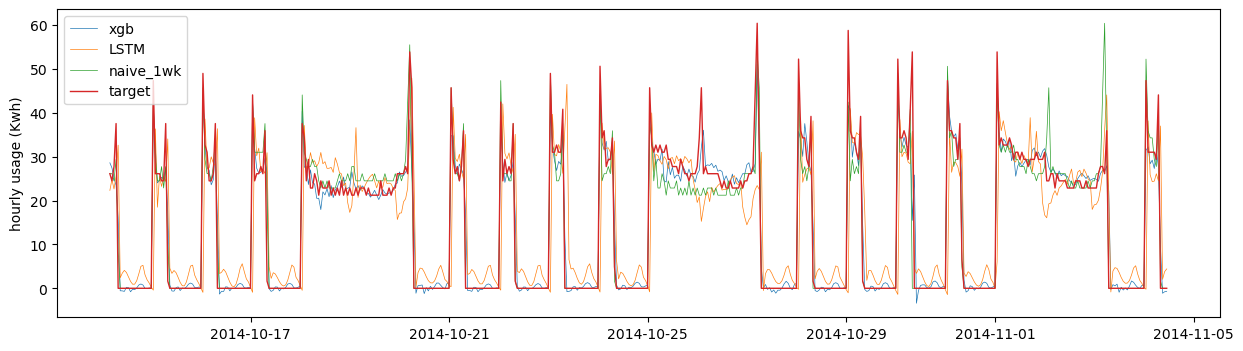

In [107]:
# plot all predictions for a bad client

#TODO: actually check that top/bottom five worst are indeed that
plt.figure(figsize=(15, 4))
linewidth_others = 0.5


start_idx = 128*40
idx_range_to_plot = int(4*128)
client_to_plot = 132

datetimes = df_all_preds_filtered.index.get_level_values('datetime')
df_all_preds_for_plot = df_all_preds_filtered[df_all_preds_filtered.index.get_level_values('client_id') == client_to_plot].iloc[start_idx: start_idx + idx_range_to_plot]


plt.plot(datetimes[start_idx: start_idx + idx_range_to_plot], df_all_preds_for_plot ['xgb'], label='xgb', linewidth=linewidth_others)
plt.plot(datetimes[start_idx: start_idx + idx_range_to_plot], df_all_preds_for_plot ['LSTM'], label='LSTM', linewidth=linewidth_others)
# plt.plot(datetimes[start_idx: start_idx + idx_range_to_plot], df_all_preds_for_plot ['lasso'], label='lasso', linewidth=linewidth_others)
# plt.plot(datetimes[start_idx: start_idx + idx_range_to_plot], df_all_preds_for_plot ['OLS'], label='OLS', linewidth=linewidth_others)
# plt.plot(datetimes[start_idx: start_idx + idx_range_to_plot], df_all_preds_for_plot ['naive_1hr'], label='naive_1hr', linewidth=linewidth_others)
plt.plot(datetimes[start_idx: start_idx + idx_range_to_plot], df_all_preds_for_plot ['naive_1wk'], label='naive_1wk', linewidth=linewidth_others)
plt.plot(datetimes[start_idx: start_idx + idx_range_to_plot], df_all_preds_for_plot ['y_true'], label='target', linewidth=1.0)



plt.ylabel('hourly usage (Kwh)')
plt.legend()
plt.show()

In [ ]:
# df_preds_corr = df_all_preds_filtered.corr()

In [28]:
# load in standardised data

with open('../data/processed/df_tabular_test.pkl', 'rb') as f:
    y_preds_standardised = pkl.load(f)['hourly_usage_kwh']

In [30]:
std_per_client = y_preds_standardised.to_frame().groupby(level='client_id').std()

In [97]:
coeff_var = df_all_preds_filtered.groupby(level='client_id')['y_true'].std()/df_all_preds_filtered.groupby(level='client_id')['y_true'].mean()
highest_5_cv = coeff_var.sort_values().iloc[-10:]
# normalised_variance.sort_values().iloc[:10]
highest_5_cv

# convert index to string
highest_5_cv.index = highest_5_cv.index.astype(str)

In [59]:
with open('../logs/XGBoost/nrmse_per_client.json', 'r') as f:
    XGBoost_per_client_nrmse = json.load(f)

with open('../logs/lasso/nrmse_per_client.json', 'r') as f:
    lasso_per_client_nrmse = json.load(f)

with open('../logs/OLS/nrmse_per_client.json', 'r') as f:
    OLS_per_client_nrmse = json.load(f)

with open('../logs/naive_1hr/nrmse_per_client.json', 'r') as f:
    naive_1hr_per_client_nrmse = json.load(f)

with open('../logs/naive_1wk/nrmse_per_client.json', 'r') as f:
    naive_1wk_per_client_nrmse = json.load(f)

with open('../logs/LSTM/nrmse_per_client.json', 'r') as f:
    LSTM_per_client_nrmse = json.load(f)
    client_ids = list(LSTM_per_client_nrmse.keys())
    LSTM_values = list(LSTM_per_client_nrmse.values())

In [60]:
df_all_nrmse = pd.DataFrame({
                            'naive_1hr': naive_1hr_per_client_nrmse, 
                            'naive_1wk': naive_1wk_per_client_nrmse, 
                            'OLS': OLS_per_client_nrmse, 
                            'lasso': lasso_per_client_nrmse, 
                            'xgb': XGBoost_per_client_nrmse, 
                            'LSTM': LSTM_per_client_nrmse, 
                            }, index=client_ids)

In [98]:
# drop clients with highest cv
df_minus_CV_clients = df_all_nrmse[~df_all_nrmse.index.isin(highest_5_cv.index)]
df_CV_clients = df_all_nrmse[df_all_nrmse.index.isin(highest_5_cv.index)]

In [106]:
# df_CV_clients
df_all_nrmse.mean(axis=1).sort_values().iloc[-10:]

136    0.177929
80     0.192561
84     0.192620
23     0.207590
343    0.239243
164    0.249645
354    0.298100
36     0.332914
366    0.384960
132    0.698126
dtype: float64

In [100]:
df_minus_CV_clients.mean()

naive_1hr    0.129219
naive_1wk    0.132312
OLS          0.084196
lasso        0.096487
xgb          0.070836
LSTM         0.108840
dtype: float64

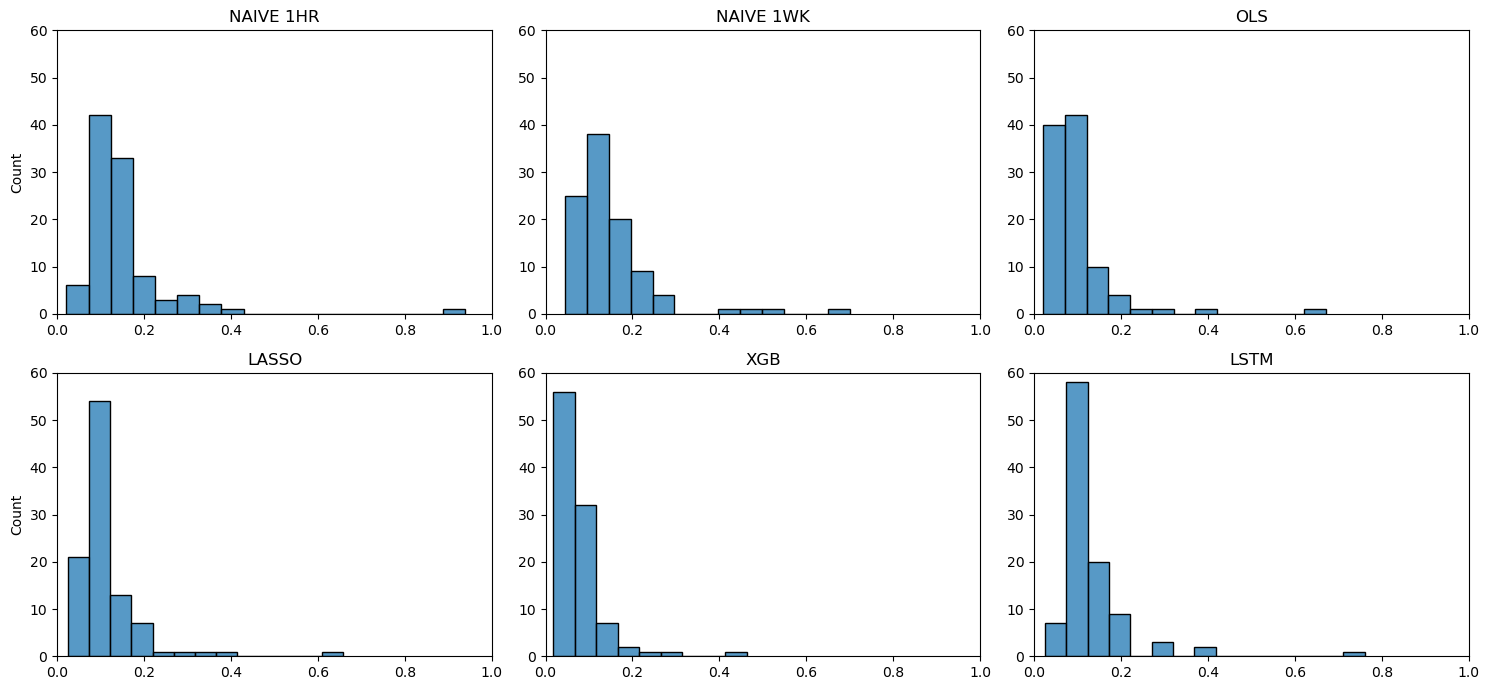

In [146]:
# create histogram of errors across clients

fig, axis = plt.subplots(2, 3, figsize=(15, 7))

for i, ax in enumerate(axis.flatten()):

    sns.histplot(data=df_all_nrmse.iloc[:, i], ax=ax, binwidth=0.05)
    ax.set_xlabel('')
    if i == 0 or i == 3:
        ax.set_ylabel('Count')
    else:
        ax.set_ylabel('')
    ax.set_title(f'{df_all_nrmse.columns[i]}'.replace('_', ' ').upper())
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 60])
# plt.suptitle('Per-client error distribution', fontsize=30)
plt.tight_layout()
plt.savefig('../plots/client_error_histogram.png')
plt.show()